In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import trange
import ot

In [22]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return self.logsoftmax(x)

In [19]:
transform = transforms.ToTensor()

# ----------------------------
# 1. Load full MNIST datasets
# ----------------------------
full_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
full_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# ----------------------------
# 2. Select indices for digits 0–4 and 5–9
# ----------------------------

# Training split
indices_A_train = [i for i, (_, y) in enumerate(full_train) if y <= 4]
indices_B_train = [i for i, (_, y) in enumerate(full_train) if y >= 5]

# Testing split
indices_A_test = [i for i, (_, y) in enumerate(full_test) if y <= 4]
indices_B_test = [i for i, (_, y) in enumerate(full_test) if y >= 5]

# ----------------------------
# 3. Create Subsets
# ----------------------------
subsetA_train = Subset(full_train, indices_A_train)
subsetB_train = Subset(full_train, indices_B_train)

subsetA_test = Subset(full_test, indices_A_test)
subsetB_test = Subset(full_test, indices_B_test)

# ----------------------------
# 4. Full DataLoaders
# ----------------------------
trainA_loader = DataLoader(subsetA_train, batch_size=128, shuffle=True)
trainB_loader = DataLoader(subsetB_train, batch_size=128, shuffle=True)

testA_loader  = DataLoader(subsetA_test, batch_size=512, shuffle=False)
testB_loader  = DataLoader(subsetB_test, batch_size=512, shuffle=False)

full_train_loader = DataLoader(full_train, batch_size=128, shuffle=True)
full_test_loader  = DataLoader(full_test, batch_size=512, shuffle=False)

# Diagnostics
print("Train A size:", len(subsetA_train))
print("Train B size:", len(subsetB_train))
print("Test A size:", len(subsetA_test))
print("Test B size:", len(subsetB_test))
print("Full train:", len(full_train))
print("Full test:", len(full_test))


Train A size: 30596
Train B size: 29404
Test A size: 5139
Test B size: 4861
Full train: 60000
Full test: 10000


In [23]:
def train_model(model, dataset, epochs=3, lr=0.1, weight_decay=1e-4, batch_size=256, verbose=True):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum = 0, dampening = 0 , weight_decay = 0)
    criterion = nn.NLLLoss()
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {running/len(loader.dataset):.4f}")
    return model

In [24]:
print("Training Model A on subset A...")
modelA = train_model(MLP(), subsetA_train)
print("Training Model B on subset B...")
modelB = train_model(MLP(), subsetB_train)
print("Training Full Model on full training dataset")
modelFull = train_model(MLP(), full_train)


stateA = modelA.state_dict()
stateB = modelB.state_dict()
modelFull_state = modelFull.state_dict()


# torch.save(modelA.state_dict(), "modelA.pt")
# torch.save(modelB.state_dict(), "modelB.pt")
# torch.save(modelFull.state_dict(), "modelFull.pt")
# print("Saved modelA.pt, modelB.pt, and modelFull.pt")

Training Model A on subset A...
Epoch 1/3 - loss: 0.6482
Epoch 2/3 - loss: 0.1397
Epoch 3/3 - loss: 0.1182
Training Model B on subset B...
Epoch 1/3 - loss: 0.9293
Epoch 2/3 - loss: 0.2432
Epoch 3/3 - loss: 0.1923
Training Full Model on full training dataset
Epoch 1/3 - loss: 1.0171
Epoch 2/3 - loss: 0.3559
Epoch 3/3 - loss: 0.2895


In [25]:
def evaluate_model_state_dict(state_dict,test_loader,model_cls=MLP):
    m = model_cls()
    m.load_state_dict(state_dict)
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

print("Eval Model A:", evaluate_model_state_dict(stateA,full_test_loader))
print("Eval Model B:", evaluate_model_state_dict(stateB,full_test_loader))
print("Eval Full Model:", evaluate_model_state_dict(modelFull_state,full_test_loader))

Eval Model A: 0.5003
Eval Model B: 0.4573
Eval Full Model: 0.9161


In [26]:
def interp_states(state1, state2, lam):
    out = {}
    for k in state1.keys():
        out[k] = (1 - lam) * state1[k].float() + lam * state2[k].float()
    return out

lambdas = np.linspace(0, 1, 21)
merged_naive_acc = []
for lam in lambdas:
    s = interp_states(stateA, stateB, lam)
    merged_naive_acc.append(evaluate_model_state_dict(s,full_test_loader))
print("Naive interpolation done.")

Naive interpolation done.


In [29]:

def compute_similarity(W_A, W_B):
    """
    Compute the neuron-to-neuron similarity matrix S,
    where S[i,j] = dot product between row i of W_A
    and row j of W_B.

    W_A: (out_features, in_features)
    W_B: (out_features, in_features)

    Returns:
        S: (out_features, out_features) similarity matrix
    """
    # Ensure numpy arrays
    A = np.asarray(W_A)
    B = np.asarray(W_B)

    # Dot product matrix: A @ B.T
    S = A @ B.T
    return S

def linear_assignment_problem(sim):
    """
    Given similarity matrix sim[i,j], find permutation P (as a matrix)
    that maximizes total similarity. Hungarian solves a MIN cost,
    so cost = -sim.
    """
    cost = -sim                       # maximize sim ⇒ minimize -sim
    row_ind, col_ind = linear_sum_assignment(cost)

    n = sim.shape[0]
    P = np.zeros((n, n), dtype=np.float32)
    P[row_ind, col_ind] = 1.0
    return P


def match_neurons(A, B, layers, num_steps=10):
    """
    A, B: dict layer_name -> weight matrix (numpy)
    layers: ordered list, e.g. ["fc1","fc2","fc3"]

    Returns:
        P : dict layer_name -> permutation matrix P[l]
    """

    # Initialize P[l] = identity
    P = {}
    for l in layers:
        n = A[l].shape[0]
        P[l] = np.eye(n, dtype=np.float32)

    for step in range(num_steps):
        progress = False

        # Random layer order
        order = layers.copy()
        np.random.shuffle(order)

        for idx, l in enumerate(order):

            W_A = A[l]
            W_B = B[l]

            # Determine previous layer permutation matrix
            if l == layers[0]:
                P_prev = np.eye(W_B.shape[1], dtype=np.float32)   # input dim identity
            else:
                prev_layer = layers[layers.index(l) - 1]
                # P_prev has to match input dimension:
                P_prev = P[prev_layer].T  # transpose = inverse for permutation matrix

            # Similarity under current permutations
            W_eff = P[l] @ W_B @ P_prev
            sim_old = compute_similarity(W_A, W_eff)
            mean_old = sim_old.mean()

            # Solve LAP to get better P[l]
            P_new = linear_assignment_problem(sim_old)
            W_eff_new = P_new @ W_B @ P_prev
            sim_new = compute_similarity(W_A, W_eff_new)
            mean_new = sim_new.mean()

            if mean_new > mean_old + 1e-12:
                P[l] = P_new
                progress = True

        if not progress:
            break

    return P



A = {
    "fc1": modelA.fc1.weight.detach().numpy(),
    "fc2": modelA.fc2.weight.detach().numpy(),
}

B = {
    "fc1": modelB.fc1.weight.detach().numpy(),
    "fc2": modelB.fc2.weight.detach().numpy(),
}

layers = ["fc1", "fc2"]

P = match_neurons(A, B, layers)


def apply_permutations_to_B(B_state, P, layers=["fc1","fc2"],
                            next_layer={"fc1":"fc2","fc2":"fc3"}):
    """
    Apply permutation matrices P[l] to B_state (bias-free version).

    - Permute rows of W_l using P[l]
    - Permute columns of W_{l+1} using P[l]^T
    - Does NOT modify bias terms

    Parameters
    ----------
    B_state : dict (state_dict of model B)
    P       : dict layer_name -> permutation matrix for that layer
    layers  : list of layers to match
    next_layer : dict mapping layer -> next layer

    Returns
    -------
    new_state : dict
        Permuted version of B_state
    """

    new_state = {k: v.clone() for k, v in B_state.items()}

    for l in layers:
        P_l = P[l]

        # 1. Permute ROWS of W_l  (output neurons)
        W = new_state[f"{l}.weight"].detach().cpu().numpy()
        W_new = P_l @ W
        new_state[f"{l}.weight"] = torch.from_numpy(W_new).float()

        # 2. Permute COLUMNS of W_{l+1}  (inputs to next layer)
        if l in next_layer:
            nxt = next_layer[l]
            Wn = new_state[f"{nxt}.weight"].detach().numpy()
            Wn_new = Wn @ P_l.T     # because inputs permute with Pᵀ
            new_state[f"{nxt}.weight"] = torch.from_numpy(Wn_new).float()

    return new_state


In [31]:
# 1. Run your match_neurons(A, B, layers) function
P = match_neurons(A, B, layers=["fc1","fc2"])

# 2. Permute B’s parameters
stateB_perm = apply_permutations_to_B(modelB.state_dict(), P)

# 3. Load into a fresh model
modelB_perm = MLP()
modelB_perm.load_state_dict(stateB_perm)

<All keys matched successfully>

In [32]:
lambdas = np.linspace(0, 1, 21)
merged_permuted_weights_acc2 = []
for lam in lambdas:
    s = interp_states(stateA, stateB_perm, lam)
    merged_permuted_weights_acc2.append(evaluate_model_state_dict(s,full_test_loader))
print("Interpolation of permuted weights done.")

Interpolation of permuted weights done.


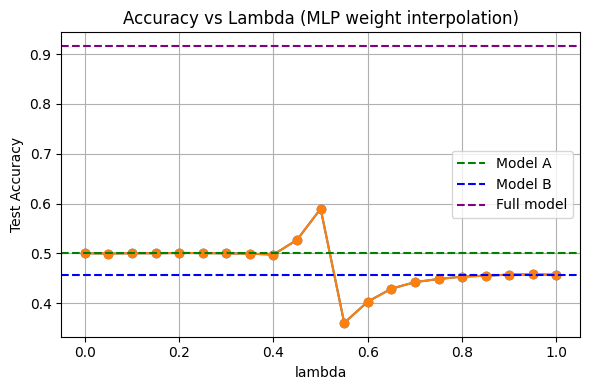

In [33]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_acc, marker='o')
plt.plot(lambdas, merged_permuted_weights_acc2, marker='o')
plt.axhline(evaluate_model_state_dict(stateA,full_test_loader), color='green', linestyle='--', label="Model A")
plt.axhline(evaluate_model_state_dict(stateB,full_test_loader), color='blue', linestyle='--', label="Model B")
plt.axhline(evaluate_model_state_dict(modelFull_state,full_test_loader), color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()